# Binary Treatment Causal Analysis


In [86]:
import warnings
import re
import sys
from pathlib import Path

import graphviz
import numpy as np
import pandas as pd
from dowhy import CausalModel
from IPython.display import display
from sklearn.exceptions import DataConversionWarning
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=DataConversionWarning)


def find_repo_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "utils" / "statistical_tests.py").exists():
            return candidate
    raise RuntimeError("Could not find repo root containing utils/statistical_tests.py")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import statistical_tests as tests


In [87]:
INPUT_FILE = "alerts_with_lib_category_and_apk_size_cryptoguard.csv"


def normalize_verdict(value):
    normalized = str(value).strip().lower()
    if normalized in {"1", "true"}:
        return 1
    if normalized in {"0", "false"}:
        return 0
    raise ValueError(f"Unsupported verdict value: {value!r}")


def normalize_rule_id(value):
    if pd.isna(value):
        return "missing"
    value = str(value).strip()
    if not value:
        return "missing"
    return re.sub(r"[^0-9A-Za-z_]+", "_", value)


def add_rule_id_columns(data):
    rule_id_dummies = pd.get_dummies(data["rule_id"], prefix="rule_id", drop_first=True, dtype=int)
    return pd.concat([data, rule_id_dummies], axis=1), list(rule_id_dummies.columns)


df = pd.read_csv(INPUT_FILE)
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].apply(normalize_verdict)
df["is_3rd_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["is_third_party"] = df["is_3rd_party"]
df["lib_category"] = df["code_location"].apply(lambda x: x if x != "developer_written" else "source")

rule_id_source_column = "rule_id" if "rule_id" in df.columns else "ruleId"
df["rule_id"] = df[rule_id_source_column].apply(normalize_rule_id)

# Combined treatment: 1 means all classified alerts are reported; 0 means developer-written-only alerts are reported.
df_all = df.copy()
df_all["combined"] = 1
df_developer_written = df[df["code_location"] == "developer_written"].copy()
df_developer_written["combined"] = 0
df = pd.concat([df_all, df_developer_written], ignore_index=True)

print("\nis_3rd_party counts:")
print(df["is_3rd_party"].value_counts())
print("\nCombined counts:")
print(df["combined"].value_counts())
print("\nVerdict value counts:")
print(df["verdict"].value_counts())
print("\nCode location value counts:")
print(df["code_location"].value_counts())
print("\nTop rule_id counts:")
print(df["rule_id"].value_counts().head(20))


Original rows: 15272
After removing obfuscated: 15272

is_3rd_party counts:
is_3rd_party
1    13954
0     2636
Name: count, dtype: int64

Combined counts:
combined
1    15272
0     1318
Name: count, dtype: int64

Verdict value counts:
verdict
0    8557
1    8033
Name: count, dtype: int64

Code location value counts:
code_location
Android              6678
others               4044
Utilities            2681
developer_written    2636
SocialMedia           463
Cloud                  51
Analytics              37
Name: count, dtype: int64

Top rule_id counts:
rule_id
13    6910
2     5658
7     1256
3     1141
10     855
1      398
8      126
9      121
14      54
11      49
12      17
4        5
Name: count, dtype: int64


In [88]:
category_order = [
    "<100",
    "100-500",
    "500-1k",
    "1k-5k",
    "5k-10k",
    "10k-50k",
    "50k-100k",
    "100k-500k",
    "500k-1M",
    "1M-5M",
    ">5M",
]

popularity_column = "app_popularity" if "app_popularity" in df.columns else "apk_category"
df["app_popularity_encoded"] = pd.Categorical(
    df[popularity_column],
    categories=category_order,
    ordered=True,
).codes

scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])

df, rule_id = add_rule_id_columns(df)

print("Popularity column:", popularity_column)
print("Rule ID effect modifier columns:", len(rule_id))
print(rule_id[:20])


Popularity column: apk_category
Rule ID effect modifier columns: 11
['rule_id_10', 'rule_id_11', 'rule_id_12', 'rule_id_13', 'rule_id_14', 'rule_id_2', 'rule_id_3', 'rule_id_4', 'rule_id_7', 'rule_id_8', 'rule_id_9']


In [89]:
# def all_correlation_tests():
#     tests.logistic_regression_binary_to_binary(df, "is_3rd_party", "combined")
#     tests.chi_square_test_cat_to_binary(df, "is_3rd_party", "combined")

#     tests.logistic_regression_binary_to_binary(df, "is_3rd_party", "verdict")
#     tests.chi_square_test_cat_to_binary(df, "is_3rd_party", "verdict")

#     tests.logistic_regression_numeric_to_binary(df, "app_popularity_encoded", "combined")
#     tests.chi_square_test_cat_to_binary(df, "app_popularity_encoded", "combined")

#     tests.logistic_regression_numeric_to_binary(df, "app_popularity_encoded", "verdict")
#     tests.chi_square_test_cat_to_binary(df, "app_popularity_encoded", "verdict")

#     tests.chi_square_test_cat_to_binary(df, "rule_id", "verdict")

#     tests.logistic_regression_binary_to_binary(df, "combined", "verdict")
#     tests.correlation_test_treatment_to_outcome(df)


# all_correlation_tests()


In [90]:
def make_rule_id_edges(targets):
    return "\n".join(
        f"    {column} -> {target};" for column in rule_id for target in targets
    )


def make_graph(edge_lines, rule_id_targets=None):
    rule_id_edges = make_rule_id_edges(rule_id_targets or [])
    body = "\n".join(edge_lines)
    if rule_id_edges:
        body = f"{body}\n{rule_id_edges}"
    return f"""
digraph {{
{body}
}}
"""


def print_refutation(method, ref):
    print(f"\nRefuter: {method}")
    if isinstance(ref, list):
        for item in ref:
            print(item)
    else:
        print(ref)


def get_refutation_value(ref, attribute):
    if isinstance(ref, list):
        return [getattr(item, attribute, None) for item in ref]
    return getattr(ref, attribute, None)


def estimate_effect_for_config(model, identified_estimand, method_name):
    estimate_kwargs = {
        "method_name": method_name,
        "target_units": "ate",
        "test_significance": True,
    }

    if method_name == "backdoor.propensity_score_matching":
        estimate_kwargs["confidence_intervals"] = "bootstrap"
        estimate_kwargs["method_params"] = {
            "num_simulations": 300,
            "sample_size_fraction": 1.0,
            "confidence_level": 0.95,
        }

    return model.estimate_effect(identified_estimand, **estimate_kwargs)


def run_refutation_tests(model, identified_estimand, estimate):
    ref_rows = []
    refutation_methods = [
        "random_common_cause",
        "placebo_treatment_refuter",
        "data_subset_refuter",
        "dummy_outcome_refuter",
    ]

    for method in refutation_methods:
        try:
            if method == "placebo_treatment_refuter":
                ref = model.refute_estimate(
                    identified_estimand,
                    estimate,
                    method_name=method,
                    placebo_type="permute",
                    num_simulations=200,
                )
            elif method == "data_subset_refuter":
                ref = model.refute_estimate(
                    identified_estimand,
                    estimate,
                    method_name=method,
                    subset_fraction=0.8,
                    num_simulations=200,
                )
            elif method == "dummy_outcome_refuter":
                ref = model.refute_estimate(
                    identified_estimand,
                    estimate,
                    method_name=method,
                    num_simulations=200,
                )
            else:
                ref = model.refute_estimate(identified_estimand, estimate, method_name=method)

            print_refutation(method, ref)
            ref_rows.append({
                "refuter": method,
                "new_effect": get_refutation_value(ref, "new_effect"),
                "p_value": get_refutation_value(ref, "p_value"),
                "error": None,
            })
        except Exception as exc:
            print(f"\nRefuter: {method}")
            print(f"Skipped because DoWhy could not run it for this estimand: {type(exc).__name__}: {exc}")
            ref_rows.append({
                "refuter": method,
                "new_effect": None,
                "p_value": None,
                "error": f"{type(exc).__name__}: {exc}",
            })
    return ref_rows


def run_causal_analysis(config):
    print("\n" + "=" * 90)
    print(config["name"])
    print("=" * 90)

    display_graph = make_graph(config["display_edges"], config.get("display_rule_id_targets", []))
    model_graph = make_graph(config["model_edges"], config.get("model_rule_id_targets", []))
    display(graphviz.Source(display_graph))

    common_causes = config["common_causes"]
    effect_modifiers = config.get("effect_modifiers", [])
    method_name = config["method_name"]

    print("Common causes:", common_causes)
    print("Effect modifiers:", effect_modifiers if effect_modifiers else "None")
    print("Estimator:", method_name)

    model = CausalModel(
        data=df,
        treatment="combined",
        outcome="verdict",
        graph=model_graph.replace("\n", " "),
        common_causes=common_causes,
        effect_modifiers=effect_modifiers or None,
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    print("\n------- Identified estimand -------")
    print(identified_estimand)

    estimate = estimate_effect_for_config(model, identified_estimand, method_name)

    print("\n------- Causal effect estimate -------")
    print(estimate)
    estimate.interpret(method_name="textual_effect_interpreter")

    ref_rows = run_refutation_tests(model, identified_estimand, estimate)

    return {
        "graph": config["name"],
        "estimator": method_name,
        "estimate": float(estimate.value),
        "common_causes": common_causes,
        "effect_modifiers": effect_modifiers,
        "identified_estimand": identified_estimand,
        "estimate_object": estimate,
        "refutations": ref_rows,
    }


In [91]:
GRAPH_CONFIGS = [
    {
        "name": "Graph 1: is_3rd_party -> combined -> verdict",
        "display_edges": [
            "    is_3rd_party -> combined;",
            "    combined -> verdict;",
        ],
        "model_edges": [
            "    is_3rd_party -> combined;",
            "    combined -> verdict;",
        ],
        "common_causes": ["is_3rd_party"],
        "effect_modifiers": [],
        "method_name": "iv.instrumental_variable",
    },
    {
        "name": "Graph 2: rule_id -> verdict with rule_id effect modification",
        "display_edges": [
            "    is_3rd_party -> combined;",
            "    combined -> verdict;",
            "    rule_id -> verdict;",
        ],
        "model_edges": [
            "    is_3rd_party -> combined;",
            "    combined -> verdict;",
        ],
        "model_rule_id_targets": ["verdict"],
        "common_causes": ["is_3rd_party"],
        "effect_modifiers": rule_id,
        "method_name": "iv.instrumental_variable",
    },
    {
        "name": "Graph 3: app popularity without rule_id effect modification",
        "display_edges": [
            "    is_3rd_party -> combined;",
            "    app_popularity_encoded -> combined;",
            "    combined -> verdict;",
            "    app_popularity_encoded -> verdict;",
        ],
        "model_edges": [
            "    is_3rd_party -> combined;",
            "    app_popularity_encoded -> combined;",
            "    combined -> verdict;",
            "    app_popularity_encoded -> verdict;",
        ],
        "common_causes": ["is_3rd_party", "app_popularity_encoded"],
        "effect_modifiers": [],
        "method_name": "backdoor.propensity_score_matching",
    },
    {
        "name": "Graph 4: app popularity and rule_id",
        "display_edges": [
            "    is_3rd_party -> combined;",
            "    app_popularity_encoded -> combined;",
            "    combined -> verdict;",
            "    rule_id -> verdict;",
            "    app_popularity_encoded -> verdict;",
        ],
        "model_edges": [
            "    is_3rd_party -> combined;",
            "    app_popularity_encoded -> combined;",
            "    combined -> verdict;",
            "    app_popularity_encoded -> verdict;",
        ],
        "model_rule_id_targets": ["verdict"],
        "common_causes": ["is_3rd_party", "app_popularity_encoded"],
        "effect_modifiers": rule_id,
        "method_name": "backdoor.propensity_score_matching",
    },
]



Graph 1: is_3rd_party -> combined -> verdict


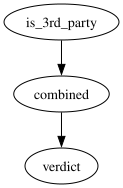

Common causes: ['is_3rd_party']
Effect modifiers: None
Estimator: iv.instrumental_variable

------- Identified estimand -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                 
───────────(E[verdict])
d[combined]            
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,,U) = P(verdict|combined,)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                      -1⎤
 ⎢       d                 ⎛       d                   ⎞  ⎥
E⎢───────────────(verdict)⋅⎜───────────────([combined])⎟  ⎥
 ⎣d[is_3rd_party]          ⎝d[is_3rd_party]            ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→verdict then ¬(U →→{is_3rd_party})
Estimand assumption 2, Exclusion: If we remove {is_3rd_party}→{combined}, then ¬({is_3rd_party}→verdict)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
E

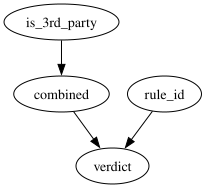

Common causes: ['is_3rd_party']
Effect modifiers: ['rule_id_10', 'rule_id_11', 'rule_id_12', 'rule_id_13', 'rule_id_14', 'rule_id_2', 'rule_id_3', 'rule_id_4', 'rule_id_7', 'rule_id_8', 'rule_id_9']
Estimator: iv.instrumental_variable

------- Identified estimand -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                 
───────────(E[verdict])
d[combined]            
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,,U) = P(verdict|combined,)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                      -1⎤
 ⎢       d                 ⎛       d                   ⎞  ⎥
E⎢───────────────(verdict)⋅⎜───────────────([combined])⎟  ⎥
 ⎣d[is_3rd_party]          ⎝d[is_3rd_party]            ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→verdict then ¬(U →→{is_3rd_party})
Estimand assumption 2, Exclusion: If we remove {is

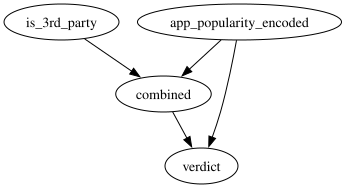

Common causes: ['is_3rd_party', 'app_popularity_encoded']
Effect modifiers: None
Estimator: backdoor.propensity_score_matching

------- Identified estimand -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                        
───────────(E[verdict|app_popularity_encoded])
d[combined]                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,app_popularity_encoded,U) = P(verdict|combined,app_popularity_encoded)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                      -1⎤
 ⎢       d                 ⎛       d                   ⎞  ⎥
E⎢───────────────(verdict)⋅⎜───────────────([combined])⎟  ⎥
 ⎣d[is_3rd_party]          ⎝d[is_3rd_party]            ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→verdict then ¬(U →→{is_3rd_party})
Estimand assumption 2, Exclusion: If we remov

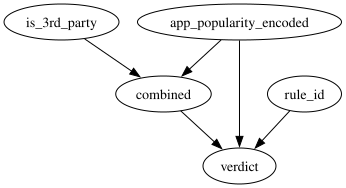

Common causes: ['is_3rd_party', 'app_popularity_encoded']
Effect modifiers: ['rule_id_10', 'rule_id_11', 'rule_id_12', 'rule_id_13', 'rule_id_14', 'rule_id_2', 'rule_id_3', 'rule_id_4', 'rule_id_7', 'rule_id_8', 'rule_id_9']
Estimator: backdoor.propensity_score_matching

------- Identified estimand -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                        
───────────(E[verdict|app_popularity_encoded])
d[combined]                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,app_popularity_encoded,U) = P(verdict|combined,app_popularity_encoded)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                      -1⎤
 ⎢       d                 ⎛       d                   ⎞  ⎥
E⎢───────────────(verdict)⋅⎜───────────────([combined])⎟  ⎥
 ⎣d[is_3rd_party]          ⎝d[is_3rd_pa

In [92]:
analysis_results = []
for config in GRAPH_CONFIGS:
    analysis_results.append(run_causal_analysis(config))


In [93]:
summary_rows = []
refutation_rows = []

for result in analysis_results:
    summary_rows.append({
        "graph": result["graph"],
        "estimator": result["estimator"],
        "estimate": result["estimate"],
        "common_causes": ", ".join(result["common_causes"]),
        "effect_modifier_count": len(result["effect_modifiers"]),
    })
    for refutation in result["refutations"]:
        refutation_rows.append({
            "graph": result["graph"],
            **refutation,
        })

summary_df = pd.DataFrame(summary_rows)
refutation_df = pd.DataFrame(refutation_rows)

print("\n" + "=" * 35 + " Estimate Summary " + "=" * 35)
print(summary_df)

print("\n" + "=" * 35 + " Refutation Summary " + "=" * 35)
print(refutation_df)



=================================== Estimate Summary ===================================
                                               graph  \
0       Graph 1: is_3rd_party -> combined -> verdict   
1  Graph 2: rule_id -> verdict with rule_id effec...   
2  Graph 3: app popularity without rule_id effect...   
3                Graph 4: app popularity and rule_id   

                            estimator  estimate  \
0            iv.instrumental_variable -0.068222   
1            iv.instrumental_variable -0.068222   
2  backdoor.propensity_score_matching  0.102230   
3  backdoor.propensity_score_matching  0.102230   

                          common_causes  effect_modifier_count  
0                          is_3rd_party                      0  
1                          is_3rd_party                     11  
2  is_3rd_party, app_popularity_encoded                      0  
3  is_3rd_party, app_popularity_encoded                     11  

=================================== Refutation 